In [2]:
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook qtconsole run script server
troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


In [3]:
!pip install transformers

In [4]:
import pandas as pd

# ---- File paths ----
my_labels_file = "labels_all.csv"
teammate_labels_file = "labels_all1.csv"
original_jobs_file = "job_data_saudi_clean.csv"   # adjust path if needed

# ---- Load label CSVs ----
df_me = pd.read_csv(my_labels_file)
df_teammate = pd.read_csv(teammate_labels_file)

# ---- Load original job data (only needed columns) ----
df_jobs = pd.read_csv(original_jobs_file, usecols=["job_id", "job_description"], low_memory=False)

# ---- Standardise column names (if your teammate's file uses different names) ----
df_teammate.rename(
    columns={"llm_category": "category", "llm_certainty": "certainty"},
    inplace=True
)

# ---- Merge label data with job descriptions ----
# Left join so every labeled job gets its description
df_me = df_me.merge(df_jobs, on="job_id", how="left")
df_teammate = df_teammate.merge(df_jobs, on="job_id", how="left")

# ---- Merge your labels with teammate's labels on job_id ----
merged = pd.merge(
    df_me,
    df_teammate,
    on="job_id",
    how="inner",
    suffixes=("_me", "_teammate")
)

# ---- Filter where category differs ----
diffs = merged[merged["category_me"] != merged["category_teammate"]]

# ---- Add a truncated description column for display ----
# (Adjust max_len to show more/less text)
max_desc_len = 1000   # adjust as needed
diffs["description_preview"] = diffs["job_description_me"].apply(
    lambda x: (str(x)[:max_desc_len] + "...") if isinstance(x, str) and len(x) > max_desc_len else str(x)
)

# ---- Select columns to display ----
cols_to_show = [
    "job_id",
    "job_title_me",                 # same in both files, we use "_me" suffix
    "description_preview",
    "sector_me",
    "sector_teammate",
    "category_me",
    "category_teammate",
    "certainty_me",
    "certainty_teammate",
]
# ---- Interactive: view full description for a specific job_id ----
job_id_to_inspect = "77a038467f741edd"   # replace with any ID from the diffs

row = diffs[diffs["job_id"] == job_id_to_inspect]
if not row.empty:
    print(f"\nFull description for job_id {job_id_to_inspect}:")
    print(row.iloc[0]["job_description_me"])
else:
    print("Job ID not found in mismatches.")

# Keep only columns that actually exist
display_cols = [c for c in cols_to_show if c in diffs.columns]

print(f"Total mismatched jobs: {len(diffs)}")
diffs[display_cols]


Full description for job_id 77a038467f741edd:
Job Title: Data Products Specialist / Data Product Analyst Location: Riyadh, Saudi Arabia Employment Type: Full-time Experience: 5+ Years Arabic Speaker Preferred Job Overview We are seeking an experienced Data Products professional to support the design, development, and enhancement of data-driven products. The role focuses on analyzing data, managing metadata and catalogs, and collaborating with business and technical teams to ensure data products deliver measurable value. Key Responsibilities Collect, analyze, and interpret data to support data product design and development. Collaborate with business stakeholders, product owners, and technical teams to define data product requirements. Support the lifecycle of data products from concept through delivery and continuous improvement. Use data cataloging tools to document datasets, metadata, lineage, and business definitions. Ensure data products are aligned with data governance standards 

C:\Users\yazze\AppData\Local\Temp\ipykernel_41528\4019818644.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diffs["description_preview"] = diffs["job_description_me"].apply(


,job_id,job_title_me,description_preview,sector_me,sector_teammate,category_me,category_teammate
1,77a038467f741edd,Data Products Specialist,Job Title: Data Products Specialist / Data Pro...,Technology & IT,Technology & IT,Data Product Analyst,Data Engineer
4,50ee957c5f397bdb,Finance Business Partner - Middle East and Africa,The Company Dexcom Corporation (NASDAQ DXCM) i...,Finance & Accounting,Finance & Accounting,Financial Analyst,Finance Business Partner
5,2d1c74ddf11baa92,Enterprise Sales Lead – Saudi Arabia,"Location Riyadh, Riyadh, Saudi Arabia Category...",Sales & Business Development,Sales & Business Development,Sales Manager,Sales Representative
9,f64748499fd604d2,Corporate Account Executive - Saudi Arabia (Re...,"As a global leader in cybersecurity, CrowdStri...",Sales & Business Development,Technology & IT,Account Executive,Sales Representative
10,300c6332db4a5526,Front-End Developer,Job Title: Data Front-End Developer Location: ...,Technology & IT,Technology & IT,Frontend Developer,Front-End Developer
...,...,...,...,...,...,...,...
13927,06dea89874b18c5d,Quality Specialist,job description: principal objective: a brief ...,Manufacturing & Production,Manufacturing & Production,Quality Specialist,Quality Inspector
13931,b648c5913857ddb0,TPE IV / Senior Telecomms Engineer,wood is currently looking for a tpe iv / senio...,Engineering,Engineering,Telecom Engineer,Telecomms Engineer
13933,78311edd8df40819,Senior Analyst - Ground and Lounge Experience,"about the company: riyadh air (rx), headquarte...",Sales & Business Development,Technology & IT,Market Research Analyst,Data Analyst
13934,56fd5219ff8fe0a0,Contract Center Specialist,premium solutions consultancy is hiring on beh...,Customer Service & Support,Customer Service & Support,Customer Service Representative,Contact Center Specialist


In [5]:
import pandas as pd

# --- Load your data (adjust paths/column names as needed) ---
df_me = pd.read_csv("labels_all.csv")
df_teammate = pd.read_csv("labels_all1.csv")

# Standardise column names if your teammate's file uses "llm_category" etc.
df_teammate.rename(
    columns={"llm_category": "category", "llm_certainty": "certainty"},
    inplace=True
)

# --- Helper function to summarise a label column ---
def taxonomy_stats(series, name):
    print(f"\n{'='*50}")
    print(f"TAXONOMY STATS: {name}")
    print(f"Unique categories: {series.nunique()}")
    print(f"Total labeled jobs  : {series.count()}")
    print(f"\nTop 20 categories:")
    print(series.value_counts().head(20))
    
    # Rare categories (appearing only once)
    rare = series.value_counts()
    rare_once = rare[rare == 1].index.tolist()
    print(f"\nCategories appearing only ONCE: {len(rare_once)}")
    if rare_once:
        print("Examples:", rare_once[:15])  # show up to 15

# --- Apply to both files ---
taxonomy_stats(df_me["category"], "Mine")
taxonomy_stats(df_teammate["category"], "Teammate")

# --- Overlap: which categories exist in both sets? ---
cats_me = set(df_me["category"].dropna().unique())
cats_teammate = set(df_teammate["category"].dropna().unique())
shared = cats_me & cats_teammate
only_mine = cats_me - cats_teammate
only_teammate = cats_teammate - cats_me

print(f"\n{'='*50}")
print("CATEGORY OVERLAP")
print(f"Shared categories: {len(shared)}")
print(f"Only in my file   : {len(only_mine)}")
print(f"Only in teammate  : {len(only_teammate)}")

if only_mine:
    print("\nExamples of categories only in my file:")
    print(list(only_mine)[:20])
if only_teammate:
    print("\nExamples of categories only in teammate's file:")
    print(list(only_teammate)[:20])

# --- Optional: same for sectors ---
print(f"\n{'='*50}")
print("SECTOR UNIQUENESS")
print(f"Mine sectors unique: {df_me['sector'].nunique()}")
print(f"Teammate sectors unique: {df_teammate['sector'].nunique()}")


TAXONOMY STATS: Mine
Unique categories: 2434
Total labeled jobs  : 13950

Top 20 categories:
category
Project Manager                 639
IT Support Specialist           359
Account Manager                 322
Cybersecurity Analyst           298
Electrical Engineer             286
Civil Engineer                  260
Sales Representative            242
Mechanical Engineer             231
Financial Analyst               209
Business Development Manager    209
Data Engineer                   182
Business Analyst                166
Software Engineer               162
Sales Engineer                  153
Cloud Engineer                  151
Data Analyst                    144
Network Engineer                142
AI Engineer                     140
Process Engineer                131
Systems Administrator           116
Name: count, dtype: int64

Categories appearing only ONCE: 1428
Examples: ['Infrastructure and Network Engineer', 'Market Research Consultant', 'Data Warehouse Consultant', 'Qua

In [6]:
import pandas as pd
import re

# ---- Load your labels (adjust path) ----
df = pd.read_csv("labels_all.csv")

# ---- Normalisation function ----
def clean_title(title):
    """
    Clean a raw job title to make it comparable with the canonical category.
    Removes seniority words, extra spaces, and lowercases.
    """
    if not isinstance(title, str):
        return ""
    t = title.lower().strip()
    # Remove common seniority prefixes
    for prefix in [
        "senior ", "junior ", "lead ", "principal ", "head ", "sr. ", "jr. ",
        "associate ", "director of ", "director ", "manager of ", "manager ",
        "global ", "regional ", "assistant ", "chief ", "vp of ", "vp ",
        "corporate ", "executive "
    ]:
        if t.startswith(prefix):
            t = t[len(prefix):].strip()
    # Remove common suffixes (e.g., " – middle east", " - riyadh")
    t = re.sub(r'[–-].*$', '', t).strip()
    # Remove words like "consultant", "specialist" at the end if they are the only difference? 
    # (Optional – for a very lenient match you could strip them, but it might cause false positives)
    # Return cleaned
    return t

# ---- Apply cleaning ----
df["cleaned_title"] = df["job_title"].apply(clean_title)
df["cleaned_category"] = df["category"].str.lower().str.strip()

# ---- Define match criteria: you have two options ----

# Option A: exact match after cleaning
df["title_matches_category"] = df["cleaned_title"] == df["cleaned_category"]

# Option B: partial containment (sometimes title contains the category, e.g. "Data Analyst - Marketing" vs "Data Analyst")
# Uncomment below to use containment instead:
# df["title_matches_category"] = df.apply(
#     lambda row: row["cleaned_category"] in row["cleaned_title"] or row["cleaned_title"] in row["cleaned_category"],
#     axis=1
# )

# ---- Output ----
print("How many job titles MATCH the predicted category?")
print(df["title_matches_category"].value_counts())
print(f"\nTotal rows: {len(df)}")

# Show examples of mismatches
mismatches = df[~df["title_matches_category"]]
print(f"\nSample of {len(mismatches)} mismatches:")
cols_to_show = ["job_id", "job_title", "category", "cleaned_title", "cleaned_category"]
display(mismatches[cols_to_show].head(20))  # for Jupyter; use print() in terminal

How many job titles MATCH the predicted category?
title_matches_category
False    9464
True     4486
Name: count, dtype: int64

Total rows: 13950

Sample of 9464 mismatches:


,job_id,job_title,category,cleaned_title,cleaned_category
0,c73ed352ab1893e9,Principal (Director) Data Science Consultant P...,Data Scientist,(director) data science consultant practice lead,data scientist
1,77a038467f741edd,Data Products Specialist,Data Product Analyst,data products specialist,data product analyst
2,b6d69309c04c90a0,Senior project manager (cloud),Project Manager,project manager (cloud),project manager
3,2423281046c56d13,"Senior Cyber Threat Intelligence Consultant, M...",Cybersecurity Analyst,"cyber threat intelligence consultant, mandiant...",cybersecurity analyst
4,50ee957c5f397bdb,Finance Business Partner - Middle East and Africa,Financial Analyst,finance business partner,financial analyst
5,2d1c74ddf11baa92,Enterprise Sales Lead – Saudi Arabia,Sales Manager,enterprise sales lead,sales manager
7,cc742edadf39b07f,Population Health Strategy Manager,Population Health Manager,population health strategy manager,population health manager
8,26ebacd29cbbebef,O&M infrastructure Engineer,Systems Administrator,o&m infrastructure engineer,systems administrator
10,300c6332db4a5526,Front-End Developer,Frontend Developer,front,frontend developer
11,fdb086becb1b7b96,"Data & Insights Manager - Sport, Entertainment...",Data Scientist,data & insights manager,data scientist


In [7]:
import pandas as pd
from ipywidgets import interact, widgets, Output, VBox, HBox
from IPython.display import display, clear_output

# -------------------------------------------------------------------------
# Load your labeled CSV (adjust path)
# -------------------------------------------------------------------------
CSV_PATH = "./labels_all.csv"   # or "labels_all.csv" for old file
df = pd.read_csv(CSV_PATH)

# Make sure 'category' column exists – if not, maybe it's 'llm_category'
if 'category' not in df.columns and 'llm_category' in df.columns:
    df.rename(columns={'llm_category': 'category'}, inplace=True)

# Add a column for full description (assuming 'job_description' exists)
# If your CSV doesn't contain job_description, you must merge it from the original jobs file.
# For this example we assume it's present.
if 'job_description' not in df.columns:
    print("ERROR: 'job_description' column not found. Merge with original jobs CSV first.")
    # You can uncomment and adjust the merge below:
    jobs_df = pd.read_csv("job_data_saudi_clean.csv")
    df = df.merge(jobs_df[['job_id','job_description']], on='job_id', how='left')

# -------------------------------------------------------------------------
# Widgets
# -------------------------------------------------------------------------
category_input = widgets.Text(
    value='Data Engineer',
    placeholder='Enter category (e.g., Data Engineer)',
    description='Category:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

page_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=0,
    step=1,
    description='Page:',
    style={'description_width': 'initial'},
    continuous_update=False,
    layout=widgets.Layout(width='400px')
)

output_area = Output()

# -------------------------------------------------------------------------
# Logic
# -------------------------------------------------------------------------
def show_page(category, page):
    filtered = df[df['category'].str.strip().str.lower() == category.strip().lower()]
    total = len(filtered)
    
    # Update slider max
    page_size = 10
    max_pages = max(0, (total - 1) // page_size)
    page_slider.max = max_pages
    page_slider.value = min(page, max_pages) if total > 0 else 0
    
    with output_area:
        clear_output(wait=True)
        if total == 0:
            print(f"No jobs found for category '{category}'")
            return
        
        start = page * page_size
        end = start + page_size
        subset = filtered.iloc[start:end]
        
        print(f"Category: '{category}'  |  Total jobs: {total}  |  Page {page+1} of {max_pages+1}")
        print("-" * 80)
        
        for idx, row in subset.iterrows():
            print(f"Job ID: {row.get('job_id','')}")
            print(f"Original title: {row.get('job_title','')}")
            print(f"Certainty: {row.get('certainty','')}")
            print(f"Reasoning: {row.get('reasoning','')}")
            print(f"Key skills: {row.get('key_skills','')}")
            print(f"Description:")
            print(row['job_description'])
            print("-" * 40)
        print(f"\nShowing {len(subset)} jobs on this page.")

# -------------------------------------------------------------------------
# Interactive callbacks
# -------------------------------------------------------------------------
def on_category_change(change):
    show_page(change['new'], page_slider.value)

def on_page_change(change):
    show_page(category_input.value, change['new'])

category_input.observe(on_category_change, names='value')
page_slider.observe(on_page_change, names='value')

# Initial display
ui = VBox([
    category_input,
    page_slider,
    output_area
])
display(ui)
show_page(category_input.value, 0)

ERROR: 'job_description' column not found. Merge with original jobs CSV first.


In [8]:
import pandas as pd

# Load the original jobs file (adjust path if needed)
jobs_df = pd.read_csv("job_data_saudi_clean.csv", usecols=["job_id", "job_title"])

def get_title(job_id):
    """Print the job title for a given job_id."""
    match = jobs_df[jobs_df["job_id"] == str(job_id)]  # force string comparison
    if match.empty:
        print(f"No job found with id '{job_id}'")
    else:
        print(f"Job ID: {match.iloc[0]['job_id']}\nTitle: {match.iloc[0]['job_title']}")


get_title("97e7a519046a6e0c")

Job ID: 97e7a519046a6e0c
Title: Data Engineer


In [9]:
import pandas as pd

# ============================================================================
# CONFIG – adjust file paths as needed
# ============================================================================
MY_FILE = "labels_all.csv"              # your labels
TEAMMATE_FILE = "labels_all1.csv"       # teammate's labels
JOBS_FILE = "job_data_saudi_clean.csv"  # original job data

# ============================================================================
# Load data
# ============================================================================
df_mine = pd.read_csv(MY_FILE)
df_teammate = pd.read_csv(TEAMMATE_FILE)

# Load jobs but ONLY keep job_id and job_description (drop job_title to avoid duplication)
df_jobs = pd.read_csv(JOBS_FILE, usecols=["job_id", "job_description"])

# Standardize category column (handle llm_category → category)
for df, name in [(df_mine, "Mine"), (df_teammate, "Teammate")]:
    if "category" not in df.columns and "llm_category" in df.columns:
        df.rename(columns={"llm_category": "category"}, inplace=True)
    if "category" not in df.columns:
        raise ValueError(f"Missing 'category' column in {name} file")

# Merge with job descriptions (inner join – only jobs present in both label files)
df_mine = df_mine.merge(df_jobs, on="job_id", how="inner")
df_teammate = df_teammate.merge(df_jobs, on="job_id", how="inner")

# ============================================================================
# Comparison function
# ============================================================================
def compare_category(category_name):
    cat = category_name.strip()
    cat_mine = set(df_mine[df_mine["category"].str.strip().str.lower() == cat.lower()]["job_id"])
    cat_teammate = set(df_teammate[df_teammate["category"].str.strip().str.lower() == cat.lower()]["job_id"])

    missed_by_me = cat_teammate - cat_mine
    missed_by_teammate = cat_mine - cat_teammate

    print(f"\nCategory: '{cat}'")
    print(f"  Your count       : {len(cat_mine)}")
    print(f"  Teammate's count : {len(cat_teammate)}")
    print(f"  Jobs teammate labeled as '{cat}' but you did NOT: {len(missed_by_me)}")
    print(f"  Jobs you labeled as '{cat}' but teammate did NOT: {len(missed_by_teammate)}")

    # -- Jobs missed by YOU --
    if missed_by_me:
        # Get the teammate's details (they have the category)
        details = df_teammate[df_teammate["job_id"].isin(missed_by_me)].copy()
        # What did YOU label them?
        my_labels = df_mine[df_mine["job_id"].isin(missed_by_me)][["job_id", "category"]].rename(
            columns={"category": "your_label"}
        )
        details = details.merge(my_labels, on="job_id", how="left")
        details["your_label"] = details["your_label"].fillna("(not in your file)")
        print(f"\n--- Jobs TEAMMATE labeled as '{cat}' that YOU labeled differently ---")
        display(details[["job_id", "job_title", "your_label", "job_description"]])
    else:
        print("No jobs missed by you.")

    # -- Jobs missed by TEAMMATE --
    if missed_by_teammate:
        details = df_mine[df_mine["job_id"].isin(missed_by_teammate)].copy()
        teammate_labels = df_teammate[df_teammate["job_id"].isin(missed_by_teammate)][["job_id", "category"]].rename(
            columns={"category": "teammate_label"}
        )
        details = details.merge(teammate_labels, on="job_id", how="left")
        details["teammate_label"] = details["teammate_label"].fillna("(not in teammate's file)")
        print(f"\n--- Jobs YOU labeled as '{cat}' that TEAMMATE labeled differently ---")
        display(details[["job_id", "job_title", "teammate_label", "job_description"]])
    else:
        print("No jobs missed by teammate.")

# ============================================================================
# Run it
# ============================================================================
#compare_category("Process Engineer")

# List of role strings you provided
roles = [
    "Database Administrator",
    "Database Analyst",
    "Database Architect",
    "Database Developer",
    "Database Engineer",
    "Database Manager",
    "Database Reliability Engineer",
    "Database Specialist"
]

# Call compare_category() for each role
for role in roles:
    result = compare_category(role)   # assuming it returns something (maybe prints internally)
    print(f"--- {role} ---")
    print(result)
    print()   # blank line between outputs


Category: 'Database Administrator'
  Your count       : 35
  Teammate's count : 24
  Jobs teammate labeled as 'Database Administrator' but you did NOT: 1
  Jobs you labeled as 'Database Administrator' but teammate did NOT: 12

--- Jobs TEAMMATE labeled as 'Database Administrator' that YOU labeled differently ---


,job_id,job_title,your_label,job_description
0,3f0defd8ec3ca515,Database Specialist,Database Specialist,Project Management Permanent Contract Mid-Seni...



--- Jobs YOU labeled as 'Database Administrator' that TEAMMATE labeled differently ---


,job_id,job_title,teammate_label,job_description
0,83945400b2fa030f,SQL & Oracle DB Engineer,Database Engineer,"Job Description: Responsible for the design, o..."
1,868f4bab2f14ed87,DB BMS Engineer,Database Engineer,Job Description: What will you do? (fill in - ...
2,4ce0032e91218d81,Senior Applications Operations Engineer,Applications Operations Engineer,Job Description Work with team members to reso...
3,7ab05cfe4f38bc40,Data Steward ECT,Data Steward,Category: Oil and Gas Industry: Oil & Gas City...
4,4ff89e70140b905c,Intern - Database Management & Systems Analysi...,Database Administrator Intern,We are WSP - Join us and make your career futu...
5,773f32f8ac5a8a36,Database Performance Engineer,Database Engineer,location: egypt / saudi arabia employment type...
6,8cbe56c435c0abb2,Senior O&M Database Engineer,Database Engineer,job description as a sql database engineer res...
7,a46a80e9d4dada09,Shared services Analyst Facalities & Inventory,Data Analyst,the shared services analyst develops and maint...
8,f8a5e282b620ed7f,Senior Database Developer and Administrator,Database Developer and Administrator,"arabic computer systems, one of the largest ic..."
9,c4b3679a67fa141e,Database management Specialist,Data Engineer,"responsibilities: collect, review, clean and m..."


--- Database Administrator ---
None


Category: 'Database Analyst'
  Your count       : 1
  Teammate's count : 1
  Jobs teammate labeled as 'Database Analyst' but you did NOT: 0
  Jobs you labeled as 'Database Analyst' but teammate did NOT: 0
No jobs missed by you.
No jobs missed by teammate.
--- Database Analyst ---
None


Category: 'Database Architect'
  Your count       : 2
  Teammate's count : 1
  Jobs teammate labeled as 'Database Architect' but you did NOT: 0
  Jobs you labeled as 'Database Architect' but teammate did NOT: 1
No jobs missed by you.

--- Jobs YOU labeled as 'Database Architect' that TEAMMATE labeled differently ---


...

--- Database Engineer ---
None


Category: 'Database Manager'
  Your count       : 3
  Teammate's count : 3
  Jobs teammate labeled as 'Database Manager' but you did NOT: 0
  Jobs you labeled as 'Database Manager' but teammate did NOT: 0
No jobs missed by you.
No jobs missed by teammate.
--- Database Manager ---
None


Category: 'Database Reliability Engineer'
  Your count       : 1
  Teammate's count : 0
  Jobs teammate labeled as 'Database Reliability Engineer' but you did NOT: 0
  Jobs you labeled as 'Database Reliability Engineer' but teammate did NOT: 1
No jobs missed by you.

--- Jobs YOU labeled as 'Database Reliability Engineer' that TEAMMATE labeled differently ---


,job_id,job_title,teammate_label,job_description
0,fe2169db8cd79d8e,Database Reliability Engineer,Database Engineer,Salla is seeking an experienced Database Relia...


--- Database Reliability Engineer ---
None


Category: 'Database Specialist'
  Your count       : 1
  Teammate's count : 0
  Jobs teammate labeled as 'Database Specialist' but you did NOT: 0
  Jobs you labeled as 'Database Specialist' but teammate did NOT: 1
No jobs missed by you.

--- Jobs YOU labeled as 'Database Specialist' that TEAMMATE labeled differently ---


,job_id,job_title,teammate_label,job_description
0,3f0defd8ec3ca515,Database Specialist,Database Administrator,Project Management Permanent Contract Mid-Seni...


--- Database Specialist ---
None



In [10]:
def get_description_by_id(job_id):
    """Return the full job_description for a given job_id."""
    match = df_jobs[df_jobs['job_id'] == str(job_id)]
    if match.empty:
        print(f"No job found with id '{job_id}'")
        return None
    desc = match.iloc[0]['job_description']
    print(desc)
    return desc


get_description_by_id("8d858b623c51bdfc")

Job Summary: The Data Engineer is responsible for supporting data integration between systems and contributing to the development and optimization of data extraction, transformation, and storage processes. The role ensures operational efficiency, accuracy, and high-quality deliverables that enable data-driven decision-making. This position requires strong analytical and communication skills in both Arabic and English, with the ability to collaborate effectively across cross-functional teams. Key Responsibilities: Develop and enhance data extraction, transformation, and loading (ETL) processes to ensure performance, scalability, and reliability. Analyze source systems to understand data relationships and design effective extraction and transformation logic. Integrate new enterprise or national systems with the data lake, ensuring efficient and secure data flow and storage. Collaborate with testing, operations, and quality teams to identify, troubleshoot, and resolve data-related issues.

'Job Summary: The Data Engineer is responsible for supporting data integration between systems and contributing to the development and optimization of data extraction, transformation, and storage processes. The role ensures operational efficiency, accuracy, and high-quality deliverables that enable data-driven decision-making. This position requires strong analytical and communication skills in both Arabic and English, with the ability to collaborate effectively across cross-functional teams. Key Responsibilities: Develop and enhance data extraction, transformation, and loading (ETL) processes to ensure performance, scalability, and reliability. Analyze source systems to understand data relationships and design effective extraction and transformation logic. Integrate new enterprise or national systems with the data lake, ensuring efficient and secure data flow and storage. Collaborate with testing, operations, and quality teams to identify, troubleshoot, and resolve data-related issues

In [11]:
def explore_keyword(keyword, df):
    keyword = keyword.lower()

    # Mask for rows where EITHER column contains the keyword (used for count & samples)
    mask = (
        df['category'].str.lower().str.contains(keyword, na=False) |
        df['category'].str.lower().str.contains(keyword, na=False)
    )
    subset = df[mask].copy()

    if subset.empty:
        print(f"\n🔍 No rows found for keyword '{keyword}'")
        return None

    # Correct: only categories from MINE that ACTUALLY contain the keyword
    mine_mask = df['category'].str.lower().str.contains(keyword, na=False)
    cats_mine = sorted(df.loc[mine_mask, 'category'].unique())

    # Correct: only categories from TEAMMATE that ACTUALLY contain the keyword
    teammate_mask = df['category'].str.lower().str.contains(keyword, na=False)
    cats_team = sorted(df.loc[teammate_mask, 'category'].unique())

    print(f"\n===== Keyword: '{keyword}' =====")
    print(f"Total matching rows (either annotator): {len(subset)}")
    print(f"\nCategories from MINE containing '{keyword}':")
    for c in cats_mine:
        print(f"   - {c}")
    print(f"\nCategories from TEAMMATE containing '{keyword}':")
    for c in cats_team:
        print(f"   - {c}")

    # Sample of the matched rows (still both sides involved)
    sample = subset.sample(min(3, len(subset)), random_state=42)
    print(f"\n--- Sample job titles & labels (up to 3) ---")
    for _, row in sample.iterrows():
        print(f"\nTitle : {row.get('job_title', 'N/A')}")
        print(f"Mine  : {row['category']}")
        print(f"Teammate: {row['category']}")
        desc = row.get('job_description', '')
        print(f"Desc  : {str(desc)[:250]}...")

    return subset

explore_keyword("Database", df_mine)


===== Keyword: 'database' =====
Total matching rows (either annotator): 57

Categories from MINE containing 'database':
   - Database Administrator
   - Database Analyst
   - Database Architect
   - Database Developer
   - Database Engineer
   - Database Manager
   - Database Reliability Engineer
   - Database Specialist

Categories from TEAMMATE containing 'database':
   - Database Administrator
   - Database Analyst
   - Database Architect
   - Database Developer
   - Database Engineer
   - Database Manager
   - Database Reliability Engineer
   - Database Specialist

--- Sample job titles & labels (up to 3) ---

Title : SQL & Oracle DBA
Mine  : Database Administrator
Teammate: Database Administrator
Desc  : Job Description: Responsibilities: Serve as Senior engineer for Microsoft SQL Server, Oracle and other database technologies. Responsible for database backup and restore functions including scheduled tests of DR availability, including knowledge of M...

Title : DB BMS Engineer
M

,job_id,job_title,company,location,sector,category,certainty,job_description
248,3fb38edc823af17f,SQL & Oracle DBA,DXC Technology,Riyadh,Technology & IT,Database Administrator,high,Job Description: Responsibilities: Serve as Se...
278,83945400b2fa030f,SQL & Oracle DB Engineer,DXC Technology,Riyadh,Technology & IT,Database Administrator,high,"Job Description: Responsible for the design, o..."
340,416297646494e455,Database Analyst - KSA,JLL,Riyadh,Technology & IT,Database Analyst,high,"JLL supports the Whole You, personally and pro..."
519,40509531ab8b5adb,Mongo DB specialist-Banking,TAWANTECH,Riyadh,Technology & IT,Database Administrator,high,Job Summary We are seeking a MongoDB Specialis...
712,c76afcc982f30d57,SQL & Oracle DBA,DXC Technology,Riyadh,Technology & IT,Database Administrator,high,"Job ID: 51563007 Location: Riyadh, Saudi Arabi..."
1549,868f4bab2f14ed87,DB BMS Engineer,Schneider Electric,Riyadh,Technology & IT,Database Administrator,medium,Job Description: What will you do? (fill in - ...
1764,86736eacfe3f4849,Database Engineer,Career Maker,Riyadh,Technology & IT,Database Engineer,high,"Key Responsibilities:- Deployment, configurati..."
2040,4ce0032e91218d81,Senior Applications Operations Engineer,Giza Systems EG,Riyadh,Technology & IT,Database Administrator,high,Job Description Work with team members to reso...
2243,fef1868e2df622ac,SQL Database Developer - KSA,DeepSource Technologies,Riyadh,Technology & IT,Database Developer,high,We are seeking a skilled Database Developer wi...
2387,5d5d5d21b55d6100,Database Administrator (DBA),TAWANTECH,Al Khobar,Technology & IT,Database Administrator,high,Job Summary: We are seeking an experienced Dat...


Total descriptions     : 13950
Max character length   : 23402
95th percentile length : 7601
99th percentile length : 9990

--- Longest job description ---
Job ID   : 0d13b86e2ccd9f2b
Job Title: Liaison Officer
Length   : 23402 characters
Summary This position is being filled under AcqDemo Direct Hiring Authority (DHA) for non-acquisition positions involving 51% or more of time in direct support of acquisition positions within Business and Technical Management Professional Career path. This is a Direct Hire Authority (DHA) solicitation utilizing the DHA for Acq Demo Business and Technical Management to recruit and appoint qualified candidates to positions in the competitive service. This job is open to The public U.S. Citizens, N...


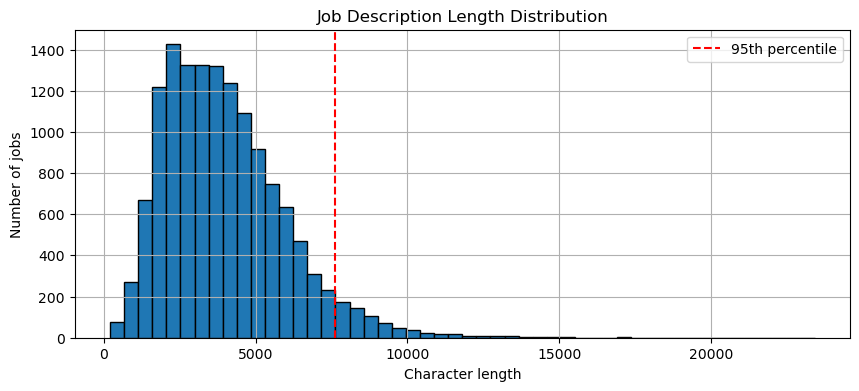

In [12]:
import pandas as pd

# --- Load your cleaned jobs CSV ---
df = pd.read_csv("job_data_saudi_clean.csv")   # adjust path if needed

# --- Calculate character lengths ---
desc_lens = df['job_description'].astype(str).str.len()

# --- Key stats ---
print(f"Total descriptions     : {len(desc_lens)}")
print(f"Max character length   : {desc_lens.max()}")
print(f"95th percentile length : {desc_lens.quantile(0.95):.0f}")
print(f"99th percentile length : {desc_lens.quantile(0.99):.0f}")

# --- Show the job with the absolute longest description ---
longest_idx = desc_lens.idxmax()
print("\n--- Longest job description ---")
print(f"Job ID   : {df.at[longest_idx, 'job_id']}")
print(f"Job Title: {df.at[longest_idx, 'job_title']}")
print(f"Length   : {desc_lens.max()} characters")
print(df.at[longest_idx, 'job_description'][:500] + "...")  # preview first 500 chars



import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
desc_lens.hist(bins=50, edgecolor='black')
plt.axvline(desc_lens.quantile(0.95), color='red', linestyle='--', label='95th percentile')
plt.xlabel('Character length')
plt.ylabel('Number of jobs')
plt.legend()
plt.title('Job Description Length Distribution')
plt.show()

In [13]:
import pandas as pd

# =============================================================================
# CONFIGURATION – set your file paths here
# =============================================================================
FILE_32B = "labels_all.csv"     # your Qwen 2.5 32B labels
FILE_8B  = "labels_all1.csv"    # teammate's Qwen 2.5 8B labels
# =============================================================================

# ---------------------------------------------------------------------------
# 1. Load the two CSVs
# ---------------------------------------------------------------------------
df32 = pd.read_csv(FILE_32B)
df8  = pd.read_csv(FILE_8B)

# ---------------------------------------------------------------------------
# 2. Standardise the category column name
# ---------------------------------------------------------------------------
for df, name in [(df32, "32B"), (df8, "8B")]:
    if "category" not in df.columns and "llm_category" in df.columns:
        df.rename(columns={"llm_category": "category"}, inplace=True)
    if "category" not in df.columns:
        raise KeyError(f"Missing 'category' column in {name} file. Columns: {df.columns.tolist()}")

# ---------------------------------------------------------------------------
# 3. Unique categories per model
# ---------------------------------------------------------------------------
cats_32b = sorted(df32["category"].dropna().unique())
cats_8b  = sorted(df8["category"].dropna().unique())

print("=" * 60)
print("UNIQUE CATEGORIES")
print(f"32B model : {len(cats_32b)}")
print(f"8B model  : {len(cats_8b)}")
print("\nAll categories (32B):")
for c in cats_32b:
    print(f"  - {c}")
print("\nAll categories (8B):")
for c in cats_8b:
    print(f"  - {c}")

# ---------------------------------------------------------------------------
# 4. Merge both datasets on job_id
# ---------------------------------------------------------------------------
merged = pd.merge(
    df32[["job_id", "job_title", "category"]],
    df8[["job_id", "category"]],
    on="job_id",
    how="inner",
    suffixes=("_32b", "_8b")
)

# ---------------------------------------------------------------------------
# 5. Find disagreements
# ---------------------------------------------------------------------------
disagree = merged[merged["category_32b"] != merged["category_8b"]]

print("\n" + "=" * 60)
print(f"TOTAL COMMON JOBS      : {len(merged)}")
print(f"JOBS WITH DISAGREEMENTS: {len(disagree)} ({len(disagree)/len(merged)*100:.1f}%)")

# ---------------------------------------------------------------------------
# 6. Show a sample of disagreements
# ---------------------------------------------------------------------------
if len(disagree) > 0:
    cols = ["job_id", "job_title", "category_32b", "category_8b"]
    # Only keep columns that actually exist
    cols = [c for c in cols if c in disagree.columns]
    print("\nSample of disagreements (first 20 rows):")
    print(disagree[cols].head(20).to_string(index=False))

    # Save the full disagreement table to a CSV for manual review
    disagree[cols].to_csv("disagreements.csv", index=False)
    print(f"\nAll {len(disagree)} disagreements saved to 'disagreements.csv'")
else:
    print("The two models completely agree on every common job.")

UNIQUE CATEGORIES
32B model : 2434
8B model  : 2446

All categories (32B):
  - 3D Architectural Renderer
  - 3D Artist
  - 3D Designer
  - 3D Geological Modeler
  - 3D Modeler and Designer
  - 4D Planner
  - ABAP Developer
  - AD Administrator
  - AFC Engineer
  - AI Architect
  - AI Business Analyst
  - AI Consultant
  - AI Data Trainer
  - AI Developer
  - AI Engineer
  - AI Engineering Manager
  - AI Infrastructure Engineer
  - AI Manager
  - AI Marketing Manager
  - AI Presales Manager
  - AI Product Manager
  - AI Research Scientist
  - AI Researcher
  - AI Strategy Consultant
  - AI Trainer
  - AIOps Architect
  - AIOps Consultant
  - API Developer
  - API Engineer
  - AV Engineer
  - AV Manager
  - AV Specialist
  - AV Support Engineer
  - Academic Advisor
  - Academy Delivery Specialist
  - Academy Director
  - Account Director
  - Account Executive
  - Account Installation Associate Analyst
  - Account Manager
  - Account Manager Intern
  - Account Receivable Specialist
  - Ac

In [14]:
import pandas as pd

df = pd.read_csv("final_labels_resolved.csv")
print(f"Total jobs : {len(df)}")
print(f"Unique labels : {df['final_category'].nunique()}")
print(df['final_category'].value_counts().head(20))

Total jobs : 13940
Unique labels : 3327
final_category
Project Manager                 518
Electrical Engineer             249
Civil Engineer                  235
Sales Representative            234
Mechanical Engineer             228
IT Support Specialist           191
Sales Engineer                  189
Data Engineer                   178
Business Analyst                164
Data Analyst                    162
Cybersecurity Analyst           160
Account Manager                 152
Business Development Manager    151
Sales Manager                   135
Process Engineer                132
Financial Analyst               123
Network Engineer                120
Solution Architect              117
Project Engineer                115
Structural Engineer             113
Name: count, dtype: int64


In [15]:
import pandas as pd

# Load your final consolidated labels
df = pd.read_csv("final_labels_resolved.csv")

# Count jobs per category, sorted from most frequent to least
cat_counts = df["final_category"].value_counts()

# Print all categories with their counts
print("FULL CATEGORY DISTRIBUTION")
print(cat_counts.to_string())

# Optionally, show only categories with fewer than N jobs (e.g., <10)
threshold = 10
rare = cat_counts[cat_counts < threshold]
print(f"\nCategories with fewer than {threshold} jobs: {len(rare)}")
print(rare.to_string())

FULL CATEGORY DISTRIBUTION
final_category
Project Manager                                            518
Electrical Engineer                                        249
Civil Engineer                                             235
Sales Representative                                       234
Mechanical Engineer                                        228
IT Support Specialist                                      191
Sales Engineer                                             189
Data Engineer                                              178
Business Analyst                                           164
Data Analyst                                               162
Cybersecurity Analyst                                      160
Account Manager                                            152
Business Development Manager                               151
Sales Manager                                              135
Process Engineer                                           132
Financial Ana

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Filtered dataset: 1,324 descriptions across 11 classes

--- Character lengths ---
Min                  : 361
Max                  : 13,879
50th percentile      : 2,842
75th percentile      : 4,066
90th percentile      : 5,321
95th percentile      : 6,203
99th percentile      : 7,550

--- Token lengths with distilbert-base-uncased ---


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1063 > 512). Running this sequence through the model will result in indexing errors


Min                  : 57
Max                  : 2617
50th percentile      : 520
75th percentile      : 761
90th percentile      : 1006
95th percentile      : 1123
99th percentile      : 1420

--- Token lengths with BAAI/bge-base-en-v1.5 ---


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1063 > 512). Running this sequence through the model will result in indexing errors


Min                  : 57
Max                  : 2617
50th percentile      : 520
75th percentile      : 761
90th percentile      : 1006
95th percentile      : 1123
99th percentile      : 1420


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1063 > 512). Running this sequence through the model will result in indexing errors


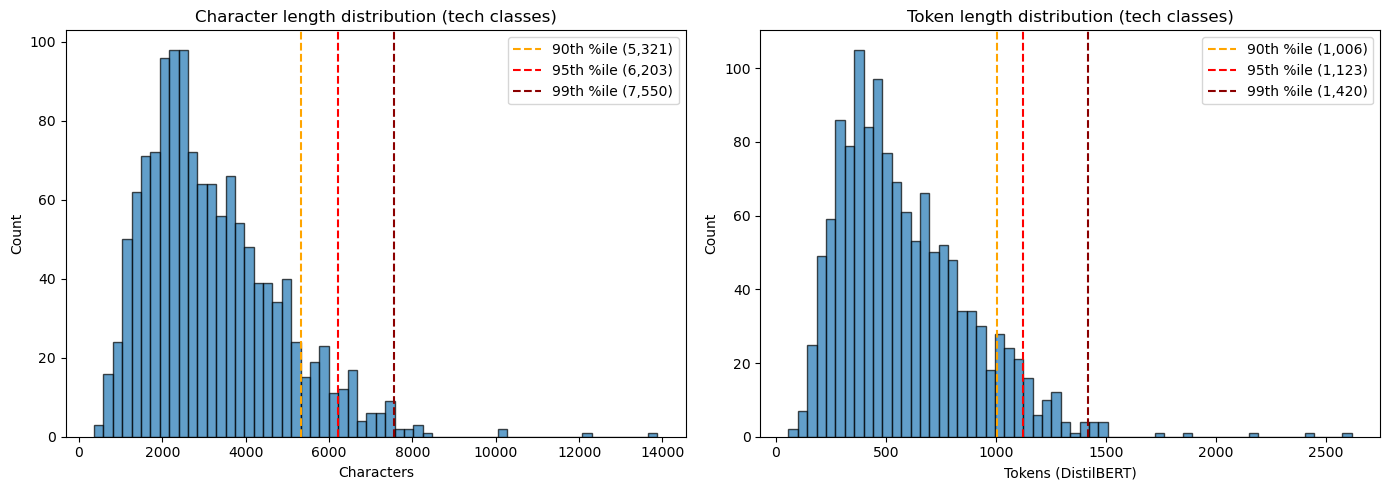

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ---------------------------------------------------------------------------
# 1. Load cleaned data & filter to the 11 tech classes
# ---------------------------------------------------------------------------
TECH_CLASSES = [
    "Data Engineer", "Business Analyst", "Data Analyst",
    "Cybersecurity Analyst", "AI Engineer", "Cloud Engineer",
    "Data Scientist", "Software Engineer", "DevOps Engineer",
    "Product Manager", "QA Engineer",
]

df = pd.read_csv("data/processed/cleaned_data.csv")
df = df[df["final_category"].isin(TECH_CLASSES)].copy()
desc = df["clean_description"].astype(str)

print(f"Filtered dataset: {len(desc):,} descriptions "
      f"across {df['final_category'].nunique()} classes")

# ---------------------------------------------------------------------------
# 2. Character‑length statistics
# ---------------------------------------------------------------------------
char_lens = desc.str.len()
print("\n--- Character lengths ---")
print(f"Min                  : {char_lens.min():,}")
print(f"Max                  : {char_lens.max():,}")
for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile      : {char_lens.quantile(p/100):,.0f}")

# ---------------------------------------------------------------------------
# 3. Token‑length statistics (pick a tokenizer relevant to your models)
# ---------------------------------------------------------------------------
# You can test multiple tokenizers, e.g.:
#   - distilbert-base-uncased    (your ensemble component)
#   - BAAI/bge-base-en-v1.5      (your retrieval model)
#   - answerdotai/ModernBERT-base (your long‑context transformer)

for tok_name in ["distilbert-base-uncased", "BAAI/bge-base-en-v1.5"]:
    print(f"\n--- Token lengths with {tok_name} ---")
    tok = AutoTokenizer.from_pretrained(tok_name)
    token_lens = desc.apply(lambda x: len(tok.encode(x, add_special_tokens=False)))
    print(f"Min                  : {token_lens.min()}")
    print(f"Max                  : {token_lens.max()}")
    for p in [50, 75, 90, 95, 99]:
        print(f"{p}th percentile      : {token_lens.quantile(p/100):.0f}")

# ---------------------------------------------------------------------------
# 4. Histogram (character lengths)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Characters
axes[0].hist(char_lens, bins=60, edgecolor='black', alpha=0.7)
for p, color in zip([90, 95, 99], ['orange', 'red', 'darkred']):
    axes[0].axvline(char_lens.quantile(p/100), color=color, linestyle='--',
                    label=f'{p}th %ile ({char_lens.quantile(p/100):,.0f})')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].set_title('Character length distribution (tech classes)')
axes[0].legend()

# Tokens (DistilBERT)
tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
token_lens = desc.apply(lambda x: len(tok.encode(x, add_special_tokens=False)))
axes[1].hist(token_lens, bins=60, edgecolor='black', alpha=0.7)
for p, color in zip([90, 95, 99], ['orange', 'red', 'darkred']):
    axes[1].axvline(token_lens.quantile(p/100), color=color, linestyle='--',
                    label=f'{p}th %ile ({token_lens.quantile(p/100):,.0f})')
axes[1].set_xlabel('Tokens (DistilBERT)')
axes[1].set_ylabel('Count')
axes[1].set_title('Token length distribution (tech classes)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
"""Review cleaned data for NaN, errors, and category distribution.

Usage: python review_data.py
"""

import pandas as pd
from pathlib import Path

# Path relative to the project root
DATA_PATH = Path("data/processed/cleaned_data.csv")

def main():
    if not DATA_PATH.exists():
        print(f"ERROR: {DATA_PATH} not found.")
        return

    df = pd.read_csv(DATA_PATH)
    print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}\n")

    # 1. Check for any NaN values in the whole DataFrame
    nan_mask = df.isna()
    if nan_mask.any().any():
        print("⚠️  NaN values found:")
        for col in nan_mask.any().index:
            count = nan_mask[col].sum()
            if count:
                print(f"  {col}: {count}")
    else:
        print("✅ No NaN values in any column.")

    # 2. Check the final_category column specifically
    if "final_category" not in df.columns:
        print("ERROR: 'final_category' column is missing.")
        return

    cats = df["final_category"]
    # Empty or whitespace-only strings
    empty_cats = cats.isna() | (cats.astype(str).str.strip() == "")
    if empty_cats.any():
        print(f"⚠️  {empty_cats.sum()} rows have an empty/missing category.")

    # 3. Category distribution
    print(f"\nUnique categories: {cats.nunique()}")
    print("\nCategory counts (sorted by frequency):")
    print(cats.value_counts().to_string())

    # 4. Identify categories that may be errors
    #    (very rare, unexpected, or containing obvious noise)
    vc = cats.value_counts()
    rare_threshold = 5
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        print(f"\nRare categories (<{rare_threshold} occurrences):")
        print(rare.to_string())

    # Check for categories that look like placeholders or contain "error"
    suspect = cats[cats.astype(str).str.lower().str.contains("error|none|null|undefined")]
    if not suspect.empty:
        print(f"\n⚠️  {len(suspect)} rows with suspicious category names (error/none/null/undefined):")
        print(suspect.value_counts().to_string())

    # 5. Check the clean_description column for empty strings
    if "clean_description" in df.columns:
        desc_col = df["clean_description"]
        empty_desc = desc_col.astype(str).str.strip() == ""
        if empty_desc.any():
            print(f"\n⚠️  {empty_desc.sum()} rows have an empty or whitespace-only cleaned description.")
        else:
            print("\n✅ No empty descriptions.")

if __name__ == "__main__":
    main()

Rows: 4,885  |  Columns: ['job_id', 'clean_description', 'final_category']

✅ No NaN values in any column.

Unique categories: 37

Category counts (sorted by frequency):
final_category
Project Manager                 514
Electrical Engineer             239
Sales Representative            230
Civil Engineer                  230
Mechanical Engineer             220
IT Support Specialist           188
Sales Engineer                  184
Data Engineer                   177
Business Analyst                163
Data Analyst                    161
Cybersecurity Analyst           158
Account Manager                 150
Business Development Manager    148
Sales Manager                   132
Process Engineer                122
Network Engineer                118
Financial Analyst               118
Solution Architect              116
Project Engineer                112
Cloud Engineer                  111
Structural Engineer             110
AI Engineer                     109
Data Scientist         

In [18]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from scripts.skill_vocab import SKILLS_VOCABULARY, SKILL_SYNONYMS

# Check if the synonym mapping exists
print("'large language models' ->", SKILL_SYNONYMS.get("large language models"))

# Check if 'LLM' is in the vocabulary
print("'LLM' in vocab:", "LLM" in SKILLS_VOCABULARY)

# Check the judge's output for LLM from the new judge results
with open("data/processed/skill_judge_results.jsonl", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if rec["term"] == "LLM":
            print("Judge output for LLM:", rec.get("skills"))
            break

'large language models' -> LLM
'LLM' in vocab: True
Judge output for LLM: ['Large Language Models', 'Natural Language Processing', 'TextGeneration', 'DialogueSystems', 'ContentUnderstanding', 'ModelFineTuning']
